In [1]:
# ResNet-50 + ViT Cross-Attention Fusion for Thoracic Disease Classification
# Model 3: ResNet-50 + ViT with Cross-Attention Fusion

import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import cv2
import os
from tensorflow_addons.losses import SigmoidFocalCrossEntropy
import warnings
warnings.filterwarnings('ignore')
import glob 

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
So

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Dataset configuration
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4

# Transfer learning strategy 
USE_TRANSFER_LEARNING = True
FREEZE_EPOCHS = 12  # Train ViT/Cross-attention first, then fine-tune everything

# Model configuration
CNN_FEATURE_DIM = 2048  # ResNet-50 output dimension
VIT_PATCH_SIZE = 16
VIT_EMBED_DIM = 256
VIT_NUM_HEADS = 8
VIT_NUM_LAYERS = 6
CROSS_ATTENTION_DIM = 512

# Class names (including No_Finding as you suggested)
CLASS_NAMES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass",
    "Nodule", "No Finding", "Pleural_Thickening", "Pneumonia", "Pneumothorax"
]
NUM_CLASSES = len(CLASS_NAMES)

In [3]:
# =============================================================================
# CUSTOM LAYERS AND COMPONENTS
# =============================================================================

class PatchExtractor(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError(f"embed_dim ({embed_dim}) should be divisible by num_heads ({num_heads})")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)

        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads
        })
        return config

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout
        
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        mlp_output = self.mlp(out1)
        mlp_output = self.dropout2(mlp_output, training=training)
        return self.layernorm2(out1 + mlp_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim,
            "dropout": self.dropout_rate
        })
        return config

class CrossAttentionFusion(layers.Layer):
    def __init__(self, attention_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attention_dim = attention_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout
        
        # Project CNN and ViT features to common dimension
        self.cnn_projection = layers.Dense(attention_dim)
        self.vit_projection = layers.Dense(attention_dim)
        
        # Cross-attention layer
        self.cross_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=attention_dim // num_heads,
            dropout=dropout
        )
        
        # Layer normalization and dropout
        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)

    def call(self, inputs, training=None):
        cnn_features, vit_features = inputs
        
        # Project features to common dimension
        cnn_proj = self.cnn_projection(cnn_features)
        vit_proj = self.vit_projection(vit_features)
        
        # Cross-attention: CNN features as queries, ViT features as keys/values
        attended_features = self.cross_attention(
            query=cnn_proj,
            key=vit_proj,
            value=vit_proj,
            training=training
        )
        
        # Residual connection and normalization
        output = self.layernorm(cnn_proj + self.dropout(attended_features, training=training))
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "attention_dim": self.attention_dim,
            "num_heads": self.num_heads,
            "dropout": self.dropout_rate
        })
        return config

In [4]:
# =============================================================================
# MODEL ARCHITECTURE
# =============================================================================

def create_resnet_vit_model(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES,
    patch_size=VIT_PATCH_SIZE,
    vit_embed_dim=VIT_EMBED_DIM,
    vit_num_heads=VIT_NUM_HEADS,
    vit_num_layers=VIT_NUM_LAYERS,
    cross_attention_dim=CROSS_ATTENTION_DIM
):
    """
    Create ResNet-50 + ViT with Cross-Attention Fusion model
    """
    inputs = layers.Input(shape=input_shape)
    
    # ===== ResNet-50 CNN Branch =====
    resnet_base = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
        pooling='avg'
    )
    
    # Start with frozen ResNet for transfer learning
    resnet_base.trainable = False  # Will be unfrozen later
    
    # Extract CNN features
    cnn_features = resnet_base.output  # Shape: (batch_size, 2048)
    
    # ===== Vision Transformer Branch =====
    num_patches = (IMAGE_SIZE // patch_size) ** 2
    
    # Extract patches
    patches = PatchExtractor(patch_size)(inputs)
    
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, vit_embed_dim)(patches)
    
    # Transformer blocks
    for i in range(vit_num_layers):
        encoded_patches = TransformerBlock(
            embed_dim=vit_embed_dim,
            num_heads=vit_num_heads,
            mlp_dim=vit_embed_dim * 4,
            dropout=0.1
        )(encoded_patches)
    
    # Global average pooling for ViT features
    vit_features = layers.GlobalAveragePooling1D()(encoded_patches)  # Shape: (batch_size, vit_embed_dim)
    
    # ===== Cross-Attention Fusion =====
    # Expand dimensions for cross-attention (add sequence dimension)
    cnn_features_expanded = tf.expand_dims(cnn_features, axis=1)  # (batch_size, 1, 2048)
    vit_features_expanded = tf.expand_dims(vit_features, axis=1)  # (batch_size, 1, vit_embed_dim)
    
    # Apply cross-attention fusion
    fused_features = CrossAttentionFusion(
        attention_dim=cross_attention_dim,
        num_heads=8,
        dropout=0.1
    )([cnn_features_expanded, vit_features_expanded])
    
    # Remove sequence dimension
    fused_features = tf.squeeze(fused_features, axis=1)  # (batch_size, cross_attention_dim)
    
    # ===== Classification Head =====
    x = layers.Dropout(0.3)(fused_features)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    # Multi-label classification output
    outputs = layers.Dense(num_classes, activation='sigmoid', name='predictions')(x)
    
    model = keras.Model(inputs, outputs, name='ResNet50_ViT_CrossAttention')
    return model

In [5]:
# =============================================================================
# DATA PREPROCESSING - FIXED VERSION
# =============================================================================

def preprocess_image(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)):
    """Preprocess a single image for training"""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Resize image
    image = cv2.resize(image, target_size)
    
    # Convert to RGB (repeat grayscale channel)
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    # Normalize to [0, 1]
    image = image.astype(np.float32) / 255.0
    
    return image

def create_data_generator(df, image_dir, batch_size, is_training=True):
    """Create a data generator for training/validation - FIXED VERSION"""
    def generator():
        while True:
            if is_training:
                df_batch = df.sample(n=batch_size).reset_index(drop=True)
            else:
                for i in range(0, len(df), batch_size):
                    df_batch = df.iloc[i:i+batch_size].reset_index(drop=True)
                    
                    if len(df_batch) == 0:
                        break
                    
                    images = []
                    labels = []
                    
                    for idx, row in df_batch.iterrows():
                        try:
                            # FIX: Use 'Path' column instead of 'image_path'
                            image_path = os.path.join(image_dir, row['Path'])
                            image = preprocess_image(image_path)
                            images.append(image)
                            
                            # Multi-label encoding
                            label = [row[class_name] for class_name in CLASS_NAMES]
                            labels.append(label)
                            
                        except Exception as e:
                            print(f"Error loading image {row['Path']}: {e}")
                            continue
                    
                    if len(images) > 0:
                        yield np.array(images), np.array(labels)
                        
                if not is_training:
                    break
            
            if is_training:
                images = []
                labels = []
                
                for idx, row in df_batch.iterrows():
                    try:
                        # FIX: Use 'Path' column instead of 'image_path'
                        image_path = os.path.join(image_dir, row['Path'])
                        image = preprocess_image(image_path)
                        images.append(image)
                        
                        # Multi-label encoding
                        label = [row[class_name] for class_name in CLASS_NAMES]
                        labels.append(label)
                        
                    except Exception as e:
                        print(f"Error loading image {row['Path']}: {e}")
                        continue
                
                if len(images) > 0:
                    yield np.array(images), np.array(labels)
    
    return generator

In [6]:
# Dataset Configuration
BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images")

# Verify paths exist
if not os.path.exists(CSV_PATH):
    print(f"Warning: CSV file not found at {CSV_PATH}")
if not os.path.exists(IMAGE_DIR):
    print(f"Warning: Image directory not found at {IMAGE_DIR}")

# Data Loading and Balanced Split
df = pd.read_csv(CSV_PATH)
df = df[['Path'] + CLASS_NAMES]  # Keep only needed columns

print(f"Dataset loaded: {len(df)} samples")
print(f"Columns: {df.columns.tolist()}")

# Verify dataset balance
class_counts = df[CLASS_NAMES].sum()
print("Class Distribution (confirming balance):")
print("=" * 50)
for label, count in zip(CLASS_NAMES, class_counts):
    percentage = (count / len(df)) * 100
    print(f"{label:20s}: {count:5d} ({percentage:5.2f}%)")

# Since dataset is balanced, use simple stratification
df['has_any_disease'] = (df[CLASS_NAMES].sum(axis=1) > 0).astype(int)

# Stratified split
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42,
    stratify=df['has_any_disease']
)

print(f"\nDataset Split:")
print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")

Dataset loaded: 51382 samples
Columns: ['Path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'No Finding', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Class Distribution (confirming balance):
Atelectasis         :  4788 ( 9.32%)
Cardiomegaly        :  4629 ( 9.01%)
Consolidation       :  4481 ( 8.72%)
Edema               :  4554 ( 8.86%)
Effusion            :  5000 ( 9.73%)
Emphysema           :  4467 ( 8.69%)
Fibrosis            :  5039 ( 9.81%)
Hernia              :  5590 (10.88%)
Infiltration        :  5740 (11.17%)
Mass                :  5564 (10.83%)
Nodule              :  5634 (10.96%)
No Finding          :  5000 ( 9.73%)
Pleural_Thickening  :  4831 ( 9.40%)
Pneumonia           :  6105 (11.88%)
Pneumothorax        :  4919 ( 9.57%)

Dataset Split:
Train: 41105 samples
Validation: 10277 samples


In [7]:
# =============================================================================
# TRAINING SETUP
# =============================================================================

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Create model
print("Creating ResNet-50 + ViT model...")
model = create_resnet_vit_model()

# Print model summary
model.summary()

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Use binary crossentropy for multi-label classification
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy', 'AUC']
)


Creating ResNet-50 + ViT model...
Model: "ResNet50_ViT_CrossAttention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                      

In [8]:
# =============================================================================
# CALLBACKS
# =============================================================================

# Create output directory if it doesn't exist
os.makedirs('./output', exist_ok=True)

# Model checkpoint
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='./output/resnet50_vit_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

# Transfer learning callback - unfreeze ResNet after initial training
class UnfreezeResNetCallback(tf.keras.callbacks.Callback):
    def __init__(self, unfreeze_epoch=FREEZE_EPOCHS):
        super().__init__()
        self.unfreeze_epoch = unfreeze_epoch
        self.unfrozen = False
    
    def on_epoch_begin(self, epoch, logs=None):
        if epoch == self.unfreeze_epoch and not self.unfrozen:
            print(f"\n{'='*60}")
            print(f"UNFREEZING ResNet-50 at epoch {epoch + 1}")
            print(f"{'='*60}")
            
            # Find the ResNet50 model within your hybrid model
            resnet_model = None
            for layer in self.model.layers:
                if hasattr(layer, 'layers'):  # Check if it's a nested model
                    # Look for ResNet50 application
                    if 'resnet50' in str(type(layer)).lower():
                        resnet_model = layer
                        break
                    # Alternative: check layer names
                    if any('conv' in sublayer.name and 'block' in sublayer.name 
                           for sublayer in layer.layers[:10]):  # ResNet pattern
                        resnet_model = layer
                        break
            
            if resnet_model is not None:
                # Unfreeze the ResNet model
                resnet_model.trainable = True
                print(f"Unfrozen ResNet50 model: {resnet_model.name}")
                
                # Optionally, keep early layers frozen for stability
                # for layer in resnet_model.layers[:50]:  # Keep first 50 layers frozen
                #     layer.trainable = False
                
            else:
                print("ResNet50 model not found - unfreezing all trainable layers")
                for layer in self.model.layers:
                    if hasattr(layer, 'trainable'):
                        layer.trainable = True
            
            # Reduce learning rate for fine-tuning
            old_lr = float(self.model.optimizer.learning_rate)
            new_lr = old_lr * 0.1
            self.model.optimizer.learning_rate = new_lr
            
            print(f"Reduced learning rate: {old_lr:.2e} → {new_lr:.2e}")
            print(f"Now fine-tuning entire hybrid model")
            print(f"{'='*60}\n")
            
            self.unfrozen = True

unfreeze_callback = UnfreezeResNetCallback(FREEZE_EPOCHS)

In [9]:
# =============================================================================
# TRAINING LOOP - FIXED VERSION
# =============================================================================

# Create data generators
print("Creating data generators...")
train_generator = tf.data.Dataset.from_generator(
    create_data_generator(train_df, IMAGE_DIR, BATCH_SIZE, is_training=True),
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_generator = tf.data.Dataset.from_generator(
    create_data_generator(val_df, IMAGE_DIR, BATCH_SIZE, is_training=False),
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

# Calculate steps per epoch
steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(val_df) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Start training
print("\nStarting training...")
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[checkpoint_callback, early_stopping, lr_scheduler, unfreeze_callback],
    verbose=1
)

# Save final model
model.save('./output/resnet50_vit_final_model.keras')
print("Training completed!")

Creating data generators...
Steps per epoch: 2569
Validation steps: 642

Starting training...
Epoch 1/30
2569/2569 [==============================] - ETA: 0s - loss: 0.3786 - binary_accuracy: 0.8789 - auc: 0.5110
Epoch 1: val_loss improved from inf to 0.38985, saving model to ./output\resnet50_vit_best_model.keras
2569/2569 [==============================] - 1103s 424ms/step - loss: 0.3786 - binary_accuracy: 0.8789 - auc: 0.5110 - val_loss: 0.3898 - val_binary_accuracy: 0.9008 - val_auc: 0.5627 - lr: 1.0000e-04
Epoch 2/30
2569/2569 [==============================] - ETA: 0s - loss: 0.3335 - binary_accuracy: 0.9014 - auc: 0.5438
Epoch 2: val_loss did not improve from 0.38985
2569/2569 [==============================] - 1156s 450ms/step - loss: 0.3335 - binary_accuracy: 0.9014 - auc: 0.5438 - val_loss: 0.4022 - val_binary_accuracy: 0.9009 - val_auc: 0.6138 - lr: 1.0000e-04
Epoch 3/30
2569/2569 [==============================] - ETA: 0s - loss: 0.3241 - binary_accuracy: 0.9010 - auc: 0.58

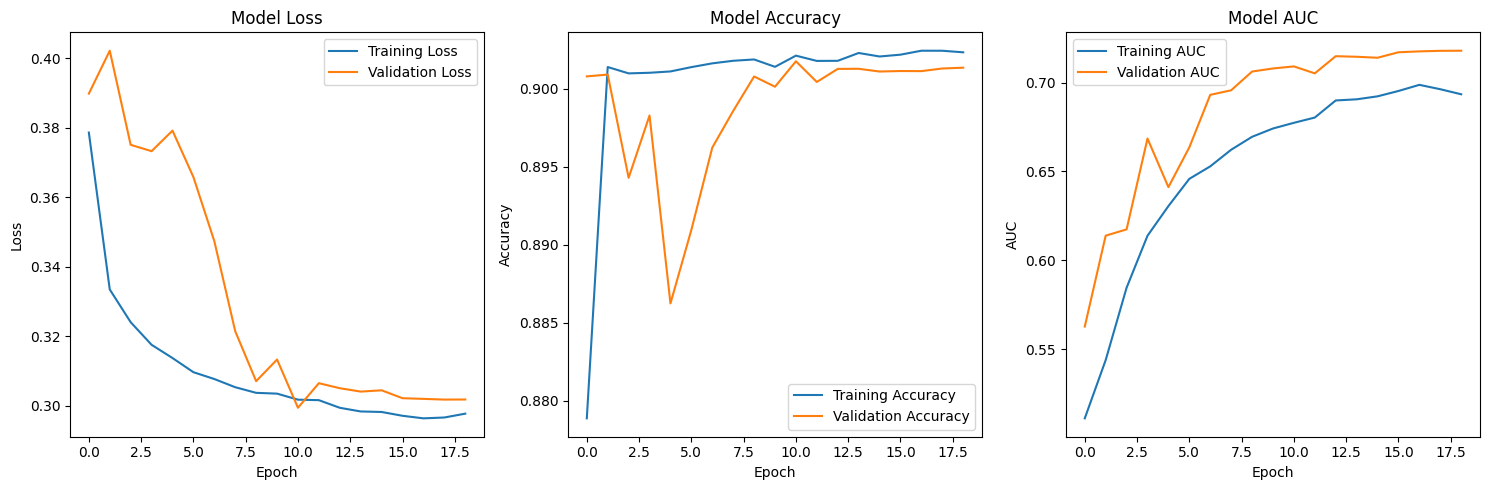


Model training completed!
Best model saved at: ./output/resnet50_vit_best_model.keras
Final model saved at: ./output/resnet50_vit_final_model.keras


In [11]:
# =============================================================================
# EVALUATION AND VISUALIZATION
# =============================================================================

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nModel training completed!")
print(f"Best model saved at: ./output/resnet50_vit_best_model.keras")
print(f"Final model saved at: ./output/resnet50_vit_final_model.keras")

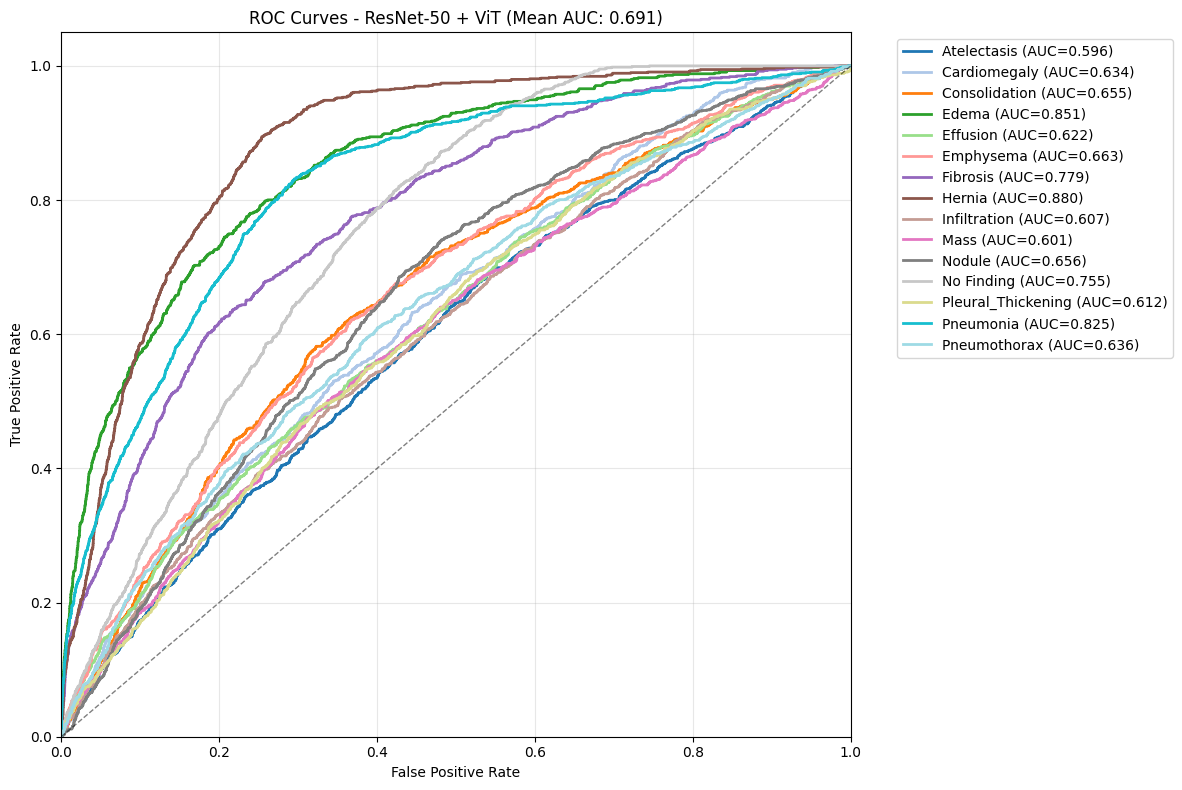

Results saved - Mean AUC: 0.6914


In [16]:
from sklearn.metrics import roc_curve, auc

def plot_results_and_save(y_true, y_pred, labels):
    """Plot ROC curves and save results"""
    plt.figure(figsize=(12, 8))
    
    aucs = []
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        if np.sum(y_true[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
            auc_score = auc(fpr, tpr)
            aucs.append(auc_score)
            plt.plot(fpr, tpr, color=color, linewidth=2,
                     label=f'{label} (AUC={auc_score:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - ResNet-50 + ViT (Mean AUC: {np.mean(aucs):.3f})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./output/roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save detailed results
    results_df = pd.DataFrame({
        'Disease': labels[:len(aucs)],
        'AUC': aucs,
        'Positive_Samples': [np.sum(y_true[:, i]) for i in range(len(aucs))]
    })
    results_df['Mean_AUC'] = np.mean(aucs)
    results_df.to_csv('./output/model_results.csv', index=False)
    
    print(f"Results saved - Mean AUC: {np.mean(aucs):.4f}")

plot_results_and_save(val_labels, val_predictions, CLASS_NAMES)